=== Model Evaluation ===
Root Mean Squared Error (RMSE): 16.54
R-squared (R2 Score): 0.7130


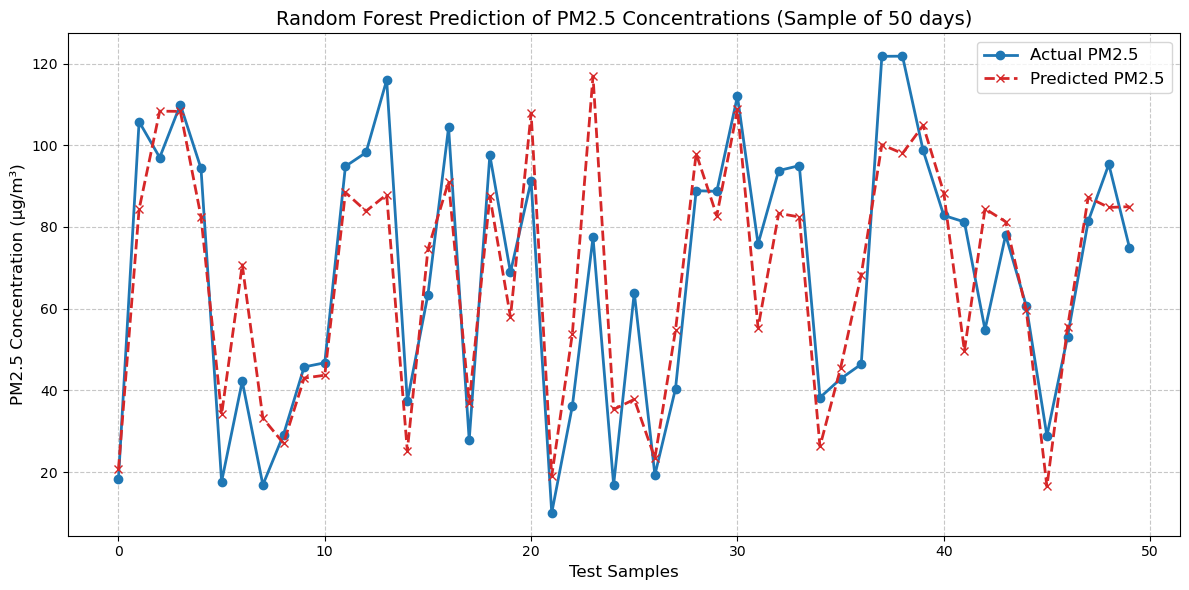

Feature 'Temperature_C' importance: 85.1%
Feature 'Humidity_Pct' importance: 4.8%
Feature 'Wind_Speed_ms' importance: 5.0%
Feature 'PM25_Lag1' importance: 5.1%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Simulate Realistic Environmental Data for Xi'an (Temporary placeholder for real CSV)
# In reality, Xi'an PM2.5 has seasonal trends (higher in winter due to heating/basin topography)
np.random.seed(42)
days = 365 # A full year of data
dates = pd.date_range(start='2025-01-01', periods=days)

# Simulating seasonal temperature and baseline PM2.5
temp = 15 + 15 * np.sin(2 * np.pi * dates.dayofyear / 365 - np.pi/2) + np.random.normal(0, 3, days)
# Higher PM2.5 in colder months
pm25_baseline = 100 - 2.5 * temp + np.random.normal(0, 15, days) 

data = pd.DataFrame({
    'Date': dates,
    'Temperature_C': temp,
    'Humidity_Pct': np.random.uniform(30, 80, days),
    'Wind_Speed_ms': np.random.uniform(0.5, 8.0, days),
    'PM25_Target': np.maximum(pm25_baseline, 10) # Ensure no negative PM2.5
})

# 2. Advanced Feature Engineering: Lag Features (Using past to predict future)
# Creating "Yesterday's PM2.5" as a feature, crucial for time-series environmental data
data['PM25_Lag1'] = data['PM25_Target'].shift(1)
data = data.dropna() # Drop the first row which has no 'yesterday' data

# 3. Define Features (X) and Target (y)
features = ['Temperature_C', 'Humidity_Pct', 'Wind_Speed_ms', 'PM25_Lag1']
X = data[features]
y = data['PM25_Target']

# 4. Train-Test Split (Chronological split is better for time series, but random is okay for now)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Build the Advanced Model: Random Forest Regressor
# RF handles non-linear environmental relationships much better than Linear Regression
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Make Predictions
y_pred = rf_model.predict(X_test)

# 7. Academic Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Model Evaluation ===")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# 8. Professional Visualization (English Only)
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual PM2.5', marker='o', color='#1f77b4', linewidth=2)
plt.plot(y_pred[:50], label='Predicted PM2.5', marker='x', color='#d62728', linestyle='--', linewidth=2)
plt.title('Random Forest Prediction of PM2.5 Concentrations (Sample of 50 days)', fontsize=14)
plt.xlabel('Test Samples', fontsize=12)
plt.ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 9. Feature Importance (Understanding what drives pollution)
importances = rf_model.feature_importances_
for feature, imp in zip(features, importances):
    print(f"Feature '{feature}' importance: {imp*100:.1f}%")

📂 正在读取西安真实历史数据...
🌲 正在训练随机森林大脑，思考中...

=== 真实数据模型评估结果 ===
RMSE (预测平均误差): 8.38 μg/m³
R2 Score (解释力): 0.9501


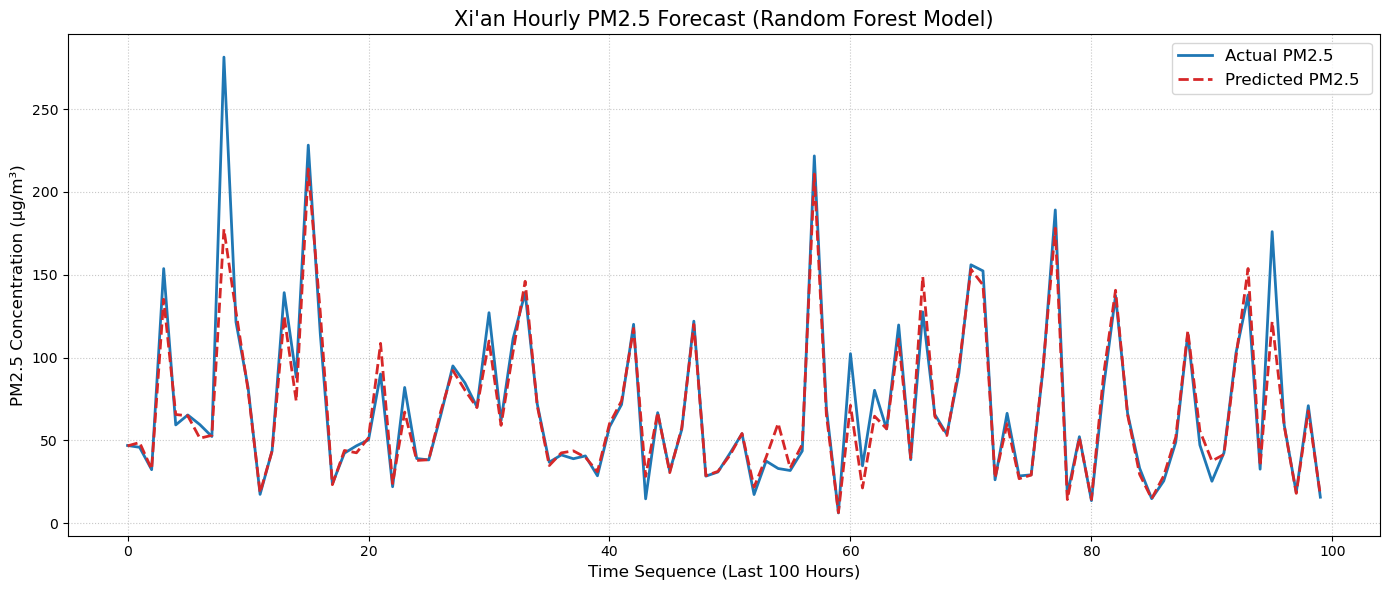


=== 特征重要性分析 (Feature Importance) ===
'Hour': 1.8%
'Month': 0.6%
'PM25_Lag1': 92.2%
'PM25_Lag2': 4.3%
'PM25_Lag24': 1.1%


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. 导入你的真实战利品！
print("📂 正在读取西安真实历史数据...")
df = pd.read_csv("xian_real_pm25_data.csv")

# 2. 学术级特征工程 (Feature Engineering for Time Series)
# 将普通的文本字符串，转换成 Python 能理解的“时间机器”
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

# 提取时间特征：供暖季（冬季）和夜间（逆温层厚）PM2.5通常更高
df['Hour'] = df['Date_Time'].dt.hour
df['Month'] = df['Date_Time'].dt.month

# 滞后特征 (Lag Features)：这是时间序列预测的灵魂
# 用过去几小时的浓度，来预测现在的浓度
df['PM25_Lag1'] = df['PM25_Target'].shift(1)  # 1小时前
df['PM25_Lag2'] = df['PM25_Target'].shift(2)  # 2小时前
df['PM25_Lag24'] = df['PM25_Target'].shift(24) # 昨天同一时间

# 删掉因为历史时间不够而产生的空值行
df = df.dropna()

# 3. 准备 X (特征集) 和 y (我们要预测的目标)
features = ['Hour', 'Month', 'PM25_Lag1', 'PM25_Lag2', 'PM25_Lag24']
X = df[features]
y = df['PM25_Target']

# 4. 划分训练集和考试集 (80% 训练，20% 考试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 训练随机森林模型
print("🌲 正在训练随机森林大脑，思考中...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 6. 考试与学术评分
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== 真实数据模型评估结果 ===")
print(f"RMSE (预测平均误差): {rmse:.2f} μg/m³")
print(f"R2 Score (解释力): {r2:.4f}")

# 7. 学术级可视化 (提取最后 100 个小时的预测曲线)
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[-100:], label='Actual PM2.5 ', color='#1f77b4', linewidth=2)
plt.plot(y_pred[-100:], label='Predicted PM2.5 ', color='#d62728', linestyle='--', linewidth=2)
plt.title('Xi\'an Hourly PM2.5 Forecast (Random Forest Model)', fontsize=15)
plt.xlabel('Time Sequence (Last 100 Hours)', fontsize=12)
plt.ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# 8. 核心归因分析：是什么在影响西安的空气质量？
print("\n=== 特征重要性分析 (Feature Importance) ===")
importances = rf_model.feature_importances_
for feature, imp in zip(features, importances):
    print(f"'{feature}': {imp*100:.1f}%")